In [1]:
from figures import *

In [2]:
# load in data
root = "/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/"

## intitialize the list of sectors 
planet_sectors = ["u42", "u43", "u44", "n42", "n70"]

light_curves = []
periodograms = []

for sector in planet_sectors:
    light_curves.append(np.load(root + f"light_curves/{sector}_lcs.npz"))
    periodograms.append(np.load(root + f"periodograms/{sector}_periodogram.npz"))

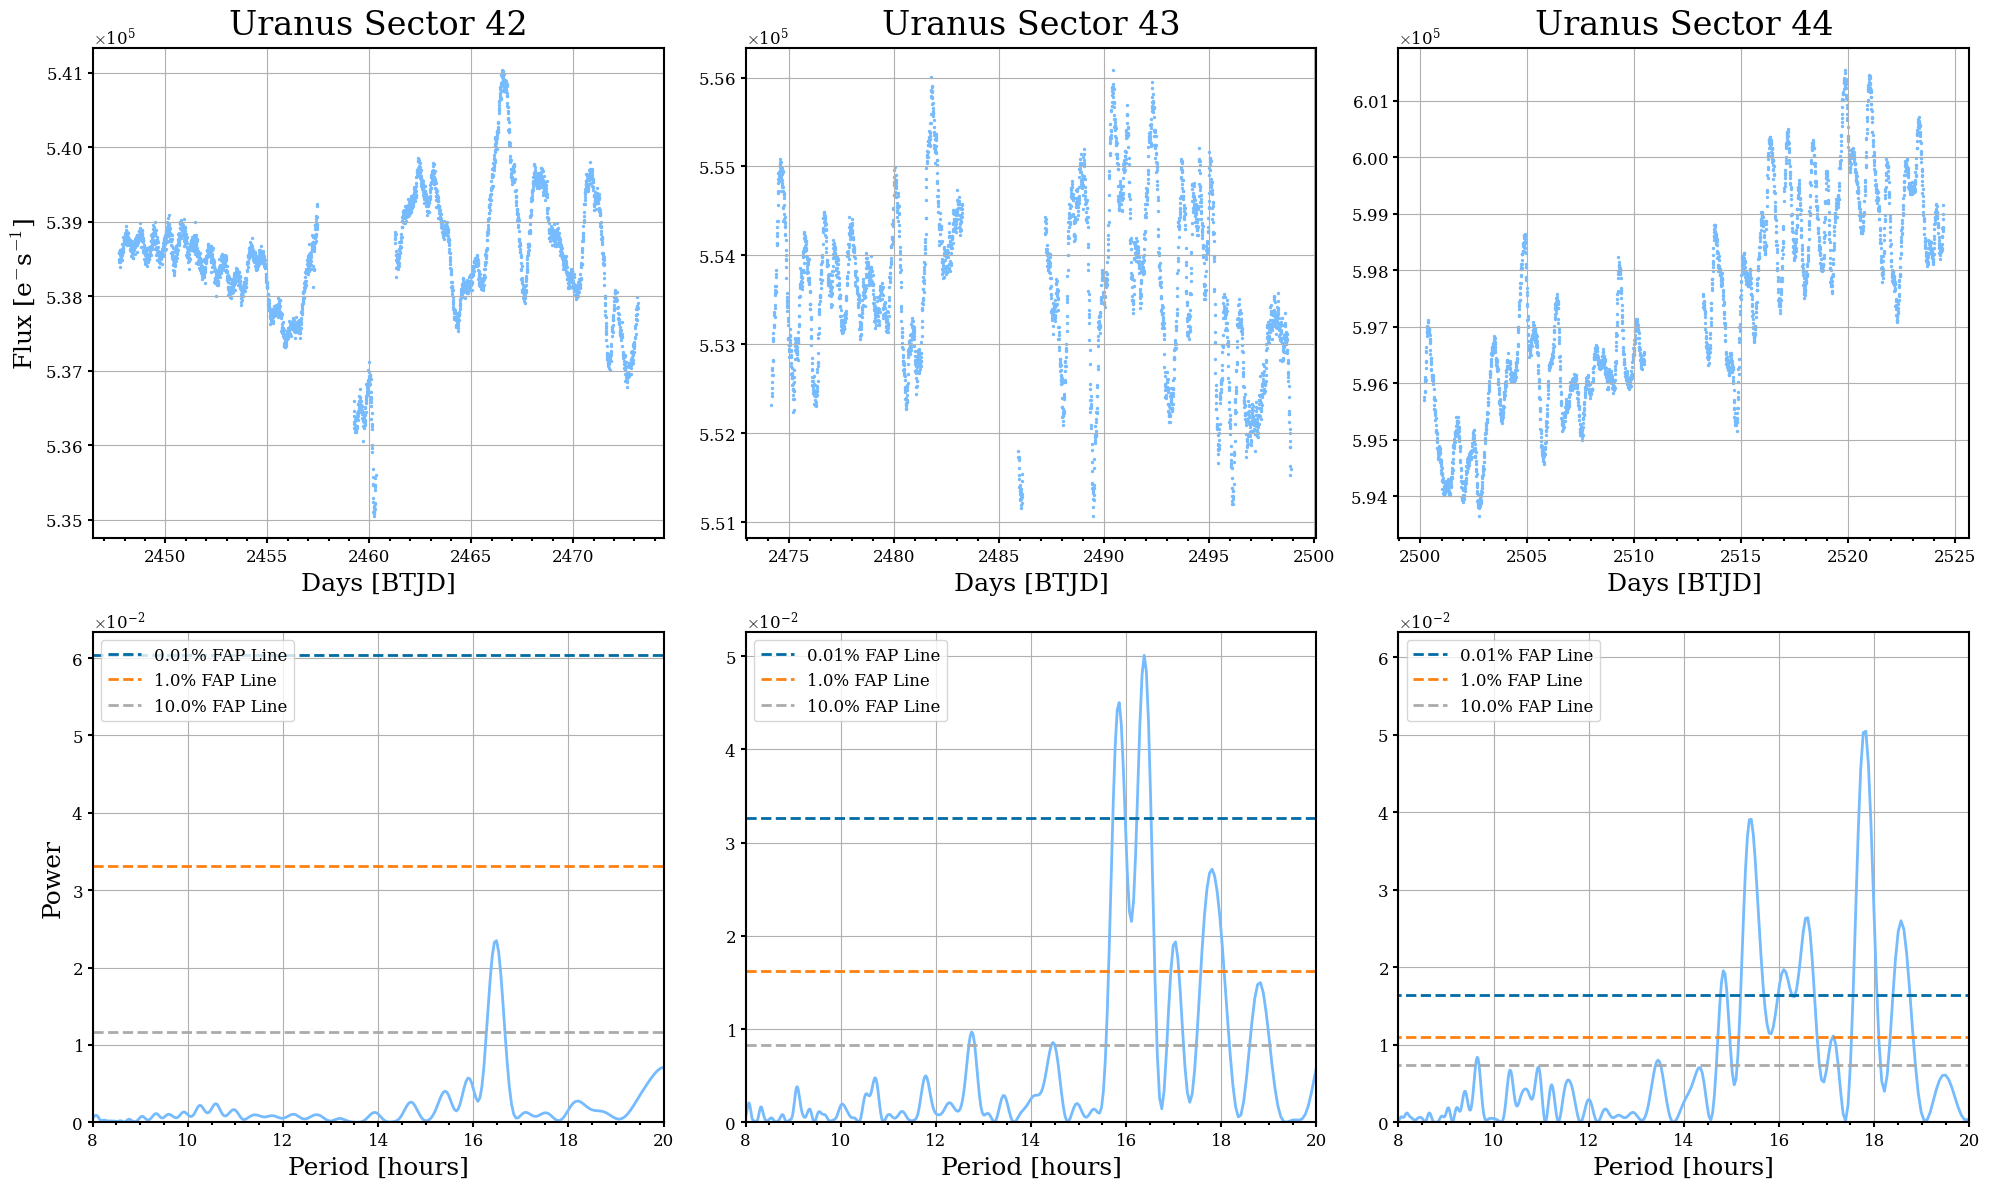

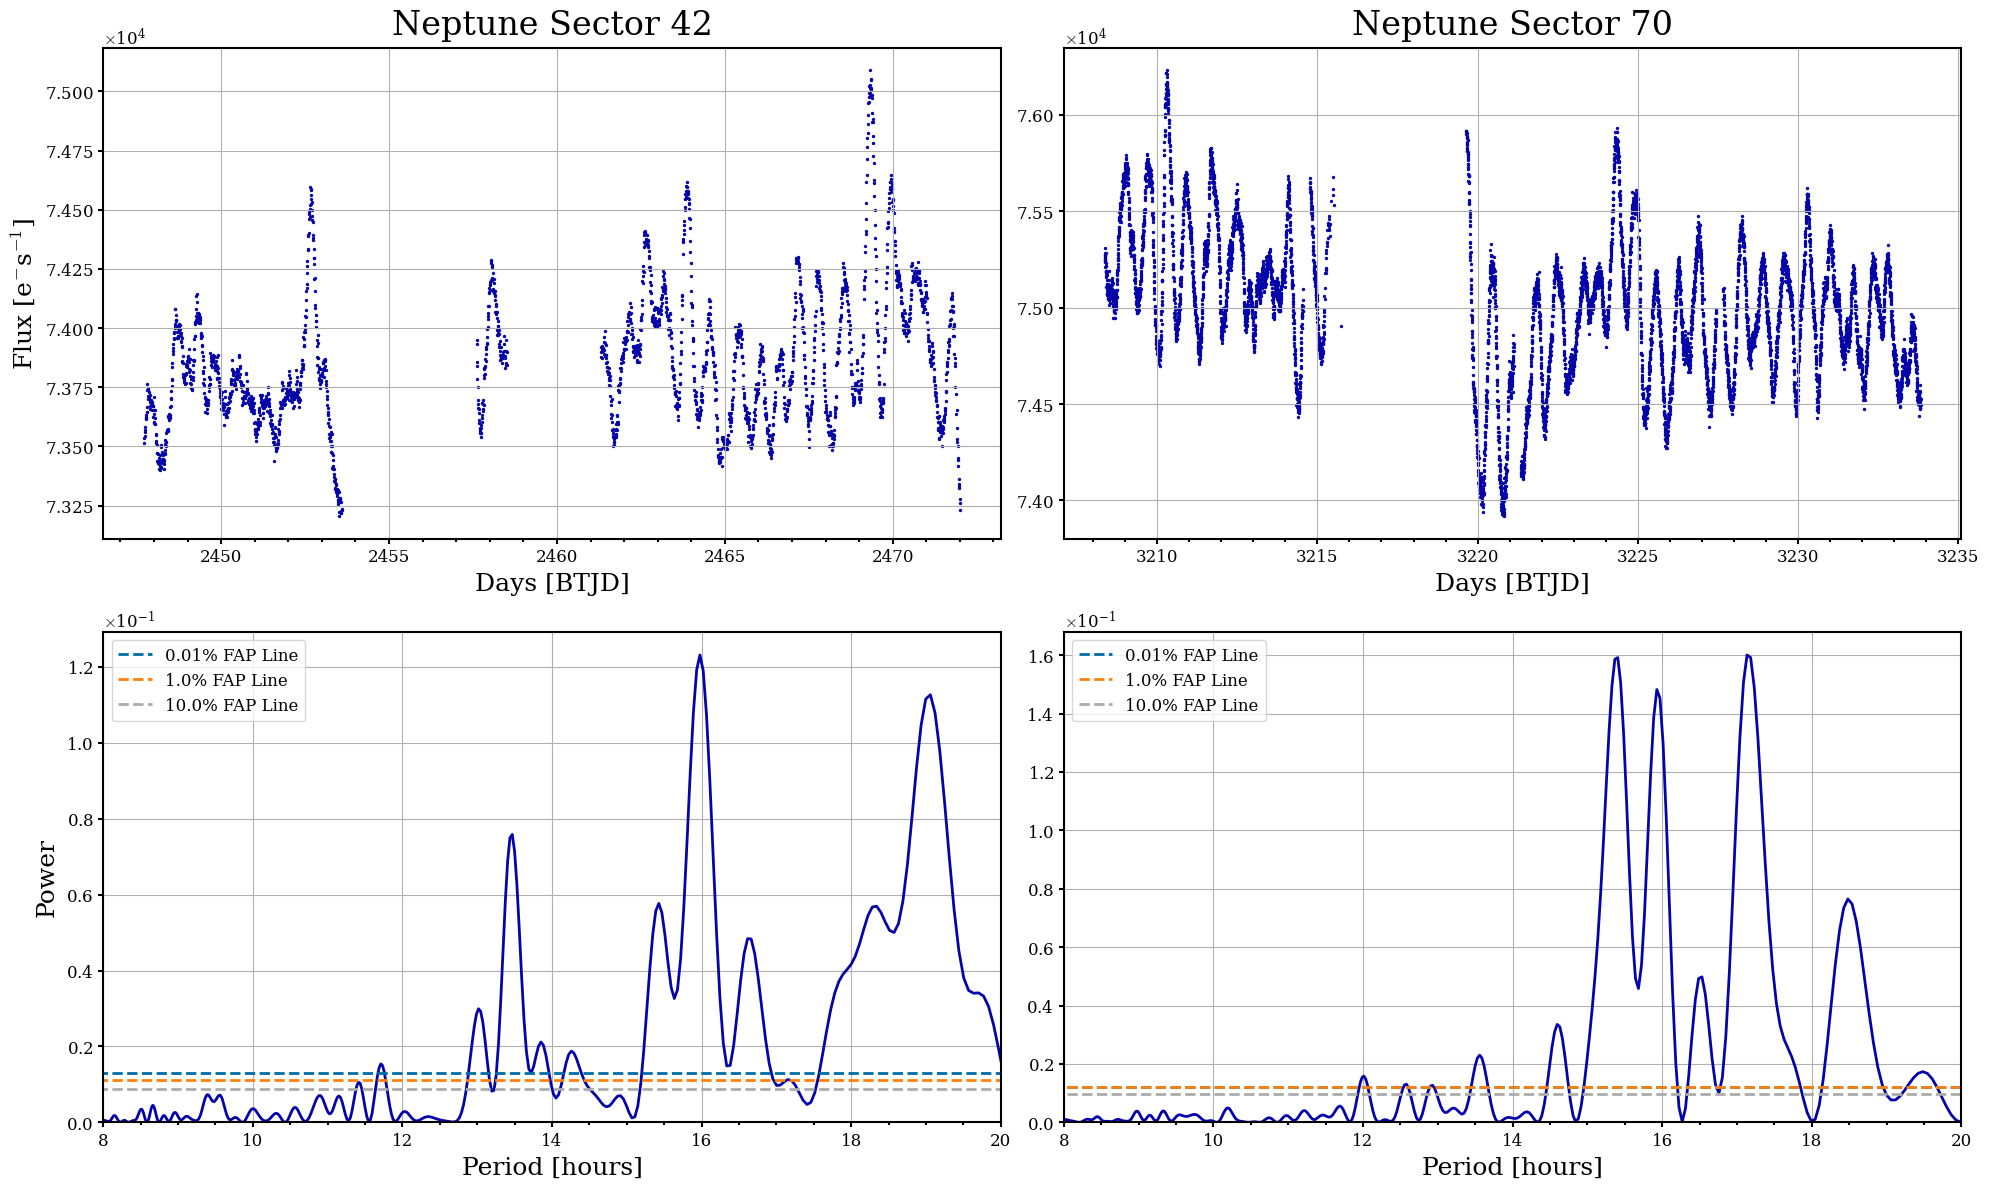

In [3]:
from figures import plot_lightcurve_and_periodogram

plot_lightcurve_and_periodogram("Uranus", 
                                light_curves[0:3], 
                                periodograms[0:3], 
                                sector_list=[42, 43, 44],
                                flux_string="orbit_corrected")
plot_lightcurve_and_periodogram("Neptune", 
                                light_curves[3:5], 
                                periodograms[3:5], 
                                sector_list=[42, 70],
                                flux_string="orbit_corrected")

KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/u42_latitude_solutions.npz' with keys: lat, std, allow_pickle)
KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/u43_latitude_solutions.npz' with keys: lat, std, allow_pickle)
KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/u44_latitude_solutions.npz' with keys: lat, std, allow_pickle)
KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/n42_latitude_solutions.npz' with keys: lat, std, allow_pickle)
KeysView(NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/latitudes/n70_latitude_solutions.npz' with keys: lat, std, allow_pickle)


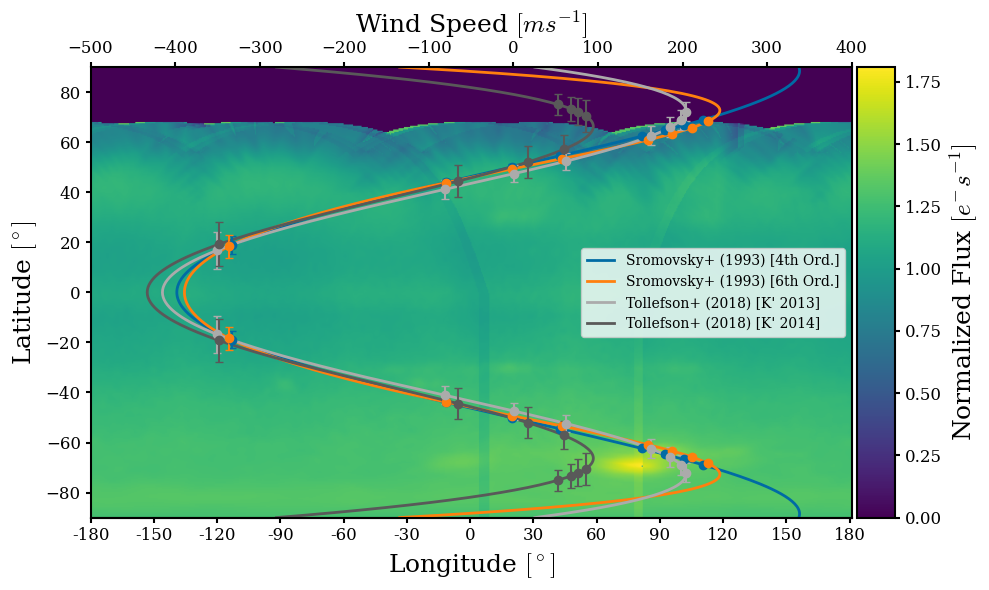

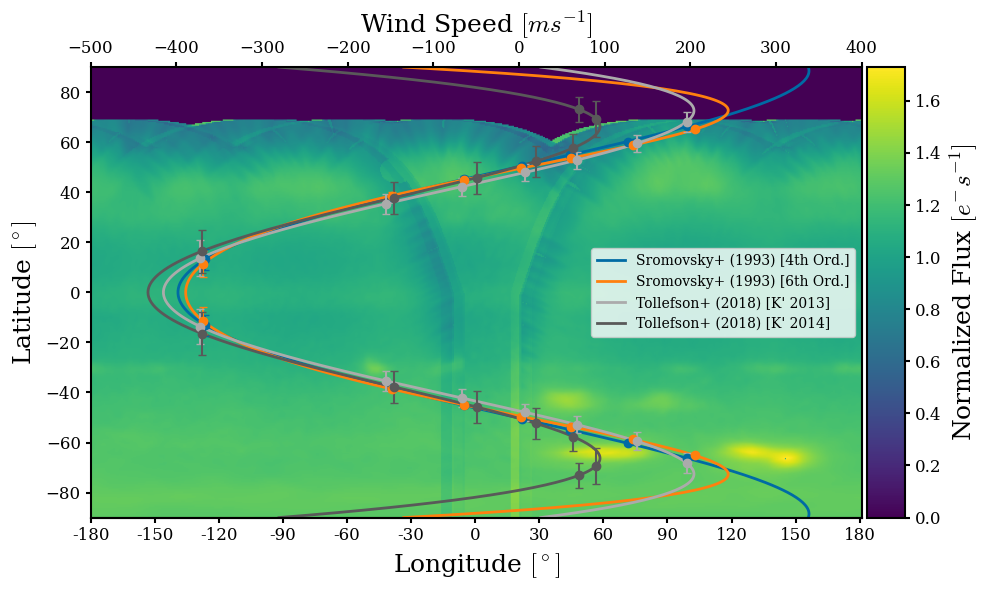

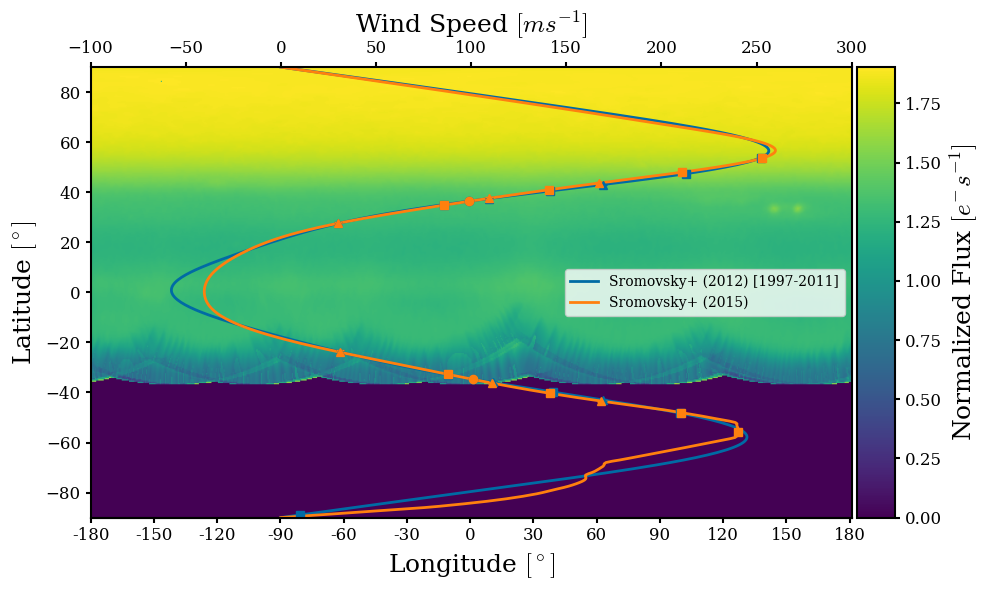

In [3]:
# lets make the opal maps 

opal_root = root + "OPAL/"
directories = [opal_root + "neptune_2021/a/", 
               opal_root + "neptune_2021/b/", 
               opal_root + "neptune_2023/a/", 
               opal_root + "neptune_2023/b/",
               opal_root + "uranus_2021/a/",
               opal_root + "uranus_2021/b/"]

root = '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/'
names = ["u42", "u43", "u44", "n42", "n70"]
new_every_lat, new_every_std = [], []
for i, latsol in enumerate(names):
    file_name = root + f"latitudes/{names[i]}_latitude_solutions.npz"
    lat = np.load(file_name, allow_pickle=True)
    print(lat.keys())
    new_every_lat.append(lat['lat'])
    new_every_std.append(lat['std'])

u42_lat, u42_std = new_every_lat[0], new_every_std[0]
u43_lat, u43_std = new_every_lat[1], new_every_std[1]
u44_lat, u44_std = new_every_lat[2], new_every_std[2]

n42_lat, n42_std = new_every_lat[3], new_every_std[3] # mask the f_0 = f solution
n70_lat, n70_std = new_every_lat[4], new_every_std[4]


n42_lat, n42_std = take_latsol_with_largest_std(n42_lat, n42_std)
n70_lat, n70_std = take_latsol_with_largest_std(n70_lat, n70_std)

u42_lat, u42_std = take_latsol_with_largest_std(u42_lat, u42_std)
u43_lat, u43_std = take_latsol_with_largest_std(u43_lat, u43_std)
u44_lat, u44_std = take_latsol_with_largest_std(u44_lat, u44_std)

#make 2nd and 4th rows of u42_lat negative

neg_u42_lat = make_rows_negative(u42_lat, [1, 3])
neg_u43_lat = make_rows_negative(u43_lat, [1, 3])
neg_u44_lat = make_rows_negative(u44_lat, [1, 3])

sromovsky1993_four = six_order_fit(-398, 1.88e-1, -1.2e-5)
sromovsky1993_six = six_order_fit(-389, 1.53e-1, 1.01e-5, -3.1e-9)

tollefson2013_kp = six_order_fit(-415, 2.35e-1, -2.23e-5)
tollefson2014_kp = six_order_fit(-433, 2.4e-1, -2.73e-5)

eqns = [sromovsky1993_four, sromovsky1993_six, tollefson2013_kp, tollefson2014_kp]

ur_eqns = [sromovsky2012_odd_N, sromovsky2015_N]

new_neg_ur_42_lat, new_u42_std = sort_ur_to_eqns(neg_u42_lat, u42_std)
new_neg_ur_43_lat, new_u43_std = sort_ur_to_eqns(neg_u43_lat, u43_std)
new_neg_ur_44_lat, new_u44_std = sort_ur_to_eqns(neg_u44_lat, u44_std)

div_stack_n21, data_stack_n21 = merge_pointings(directories[0], directories[1])
div_stack_n23, data_stack_n23 = merge_pointings(directories[2], directories[3])
div_stack_u21, data_stack_u21 = merge_pointings(directories[4], directories[5])

bright_points_n21 = plot_summed_mosaics(div_stack_n21, eqns, n42_lat, n42_std, plot_colors_rgb, 
                    planet="Neptune", sector=2021, clip_percentile=100, save=True, vmin_percentile=0, vmax_percentile=100)
bright_points_n23 = plot_summed_mosaics(div_stack_n23, eqns, n70_lat, n70_std, plot_colors_rgb, 
                    planet="Neptune", sector=2023, clip_percentile=100, save=True, vmin_percentile=0, vmax_percentile=100)
bright_points_u21 = plot_summed_mosaics(div_stack_u21, ur_eqns, [new_neg_ur_42_lat, new_neg_ur_43_lat, new_neg_ur_44_lat], 
                    [new_u42_std, new_u43_std, new_u44_std], plot_colors_rgb, 
                    planet="Uranus", sector=2021, clip_percentile=100, save=True, vmin_percentile=0, vmax_percentile=100)

In [4]:
print(u42_lat, u42_std)

[[[59.698358909649805 59.698358909649805]]

 [[58.41329984829489 58.41329984829489]]

 [[61.81468964510018 61.81468964510018]]

 [[51.73756206060543 51.73756206060543]]] [[[17.082115706848562 17.082115706848562]]

 [[17.182807503000305 17.182807503000305]]

 [[16.600927254175495 16.600927254175495]]

 [[14.069056059346464 14.069056059346464]]]


In [5]:
from subsectors import * # 6 mins

min_freq, max_freq = 1, 3
total_segs = 10

times = [sector['time'] for sector in light_curves]
fluxes = [sector['orbit_corrected'] for sector in light_curves]

subtimes, subfluxes, subfreqs, subpower, subfap = split_data(times, fluxes, 
                                                             min_freq, max_freq, 
                                                             m=50, total_segs=total_segs, 
                                                             bootstrap=True)

In [6]:
ur_offset = [2400, 2400, 2500]
uranus_labels = ["Uranus Sector 42", "Uranus Sector 43", "Uranus Sector 44"]
uranus_max_frequency = 1/17.24 #1.394

nep_offset = [2400, 3200]
nep_labels = ["Neptune Sector 42", "Neptune Sector 70"]
neptune_max_frequency = 1/18.86 #1.282201

plot_subsector_heatmap("Uranus", subtimes[0:3], subfluxes[0:3], 
                       [subfreqs]*3, subpower[0:3], 
                       subfap[0:3], labels=uranus_labels, 
                       max_freq=uranus_max_frequency, 
                       offset=ur_offset)

plot_subsector_heatmap("Neptune", subtimes[3:5], subfluxes[3:5], 
                       [subfreqs]*2, subpower[3:5], 
                       subfap[3:5], labels=nep_labels, 
                       max_freq=neptune_max_frequency, 
                       offset=nep_offset)

NameError: name 'plot_subsector_heatmap' is not defined

In [6]:
def write_solutions(arrs, sectors, i):
    first_period = np.round(24 / arrs[i].item()['all_peaks'][0][0], decimals=2)
    print(f"{sectors[i]} & {first_period}", end=" ")

    for k in range(len(arrs[i].item()['all_lat'])):
        lat = arrs[i].item()['all_lat'][k][0][0]
        std = arrs[i].item()['all_std'][k][0][0]
        print(f"& {np.round(lat, decimals=2)} ± {np.round(std, decimals=2)}", end=" ")
    
    print("\\\\")

    if len(arrs[i].item()['all_peaks'][0]) > 1:
        for j, peak in enumerate(arrs[i].item()['all_peaks'][0][1:]):
            period = 24 / peak
            print(f"& {np.round(period, decimals=2)} ", end=" ")

            for k in range(len(arrs[i].item()['all_lat'])):
                try:
                    lat = arrs[i].item()['all_lat'][k][0][j + 1]
                    std = arrs[i].item()['all_std'][k][0][j + 1]
                    print(f"& {np.round(lat, decimals=2)} ± {np.round(std, decimals=2)}", end=" ")
                except IndexError:
                    print("& -- ", end=" ")
            
            print("\\\\")        


In [45]:
sectors = ['42', '43', '44', '42', '70']

print("Sector & Period (hours) & K98_N & K98_S & H01 & S12E & S12E+O_N & S12E+O_S & FAP \\\\")
for i, arr in enumerate(arrs):

    if i == 3:
        print("Sector & Period (hours) & S93_4 & S93_6 & T2013 & T2014 & FAP \\\\")

    write_solutions(arrs, sectors, i)
    print("\hline")

Sector & Period (hours) & K98_N & K98_S & H01 & S12E & S12E+O_N & S12E+O_S & FAP \\
42 & 16.53 & [36.86 88.84] ± [1.2  0.86] & [32.45 89.07] ± [1.09 0.7 ] & [30.94 89.12] ± [1.11 0.7 ] & [34.74 88.97] ± [1.05 0.79] & [35.56 88.94] ± [0.95 0.82] & [33.61 88.94] ± [1.19 0.76] \\
\hline
43 & 17.8 & [ 9.83 89.25] ± [3.71 0.57] & [ 6.88 89.32] ± [2.84 0.51] & [22.42 89.19] ± [1.29 0.6 ] & [25.14 89.1 ] ± [1.82 0.65] & [26.97 89.1 ] ± [1.74 0.68] & [23.39 89.12] ± [1.79 0.66] \\
& 17.04  & [28.66 89.05] ± [1.29 0.72] & [89.17 24.59] ± [0.64 1.18] & [88.97 33.35] ± [0.75 1.1 ] & [36.82 88.87] ± [0.95 0.85] & [37.41 88.9 ] ± [0.85 0.84] & [35.93 88.85] ± [1.08 0.83] \\
& 16.38  & [39.29 88.71] ± [1.21 0.92] & [34.73 88.97] ± [1.08 0.77] & [88.75 41.31] ± [0.94 1.14] & [42.7  88.55] ± [0.78 1.06] & [88.57 42.84] ± [1.07 0.74] & [42.71 88.57] ± [0.9  1.07] \\
& 15.85  & [47.66 88.42] ± [1.36 1.19] & [88.74 42.48] ± [0.96 1.14] & --  & --  & --  & --  \\
\hline
44 & 17.82 & [ 8.76 89.26] ± [3.85 

In [9]:
s70_s93_4 = np.load("/home/ktp9/TESSNeptune24/tess-ice-giants/neptune_s42_resampled_mcmc_results_s93_4.npy", allow_pickle=True)
keys = ['all_lat', 'all_std', 'all_peaks']

write_solutions([s70_s93_4], ['42'], 0)

42 & 18.34 & [18.8] ± [2.13] \\
& 17.15  & [38.4] ± [1.03] \\
& 16.62  & [44.24] ± [0.89] \\
& 15.98  & [50.14] ± [0.79] \\
& 15.43  & [54.53] ± [0.71] \\
& 14.26  & [62.28] ± [0.59] \\
& 13.85  & [64.59] ± [0.56] \\
& 13.47  & [66.58] ± [0.53] \\
& 13.02  & [68.74] ± [0.5] \\
& 11.71  & [73.98] ± [0.4] \\
